In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import adfuller as adf
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [15]:
# Load the provided dataset
df = pd.read_csv('customer_churn_practice.csv')

In [16]:
# 1. Set index
# ==========================================
# Convert SignupDate to datetime and set as index to create a time series.
df['SignupDate'] = pd.to_datetime(df['SignupDate'])

# We aggregate 'MonthlyCharges' by Day ('D') to get Daily Revenue.
ts_data = df.set_index('SignupDate').resample('D')['MonthlyCharges'].sum().to_frame(name='DailyRevenue')

print(f"Data range: {ts_data.index.min()} to {ts_data.index.max()}")

Data range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00


In [17]:
# 2. Clean
# ==========================================
# Handle missing values. Since we resampled by day, some days might have no signups (NaN).
# We fill these with 0.

ts_data = ts_data.fillna(0)
print(f"Missing values after cleaning: {ts_data.isna().sum().sum()}")

Missing values after cleaning: 0


In [18]:
# 3. Stabilize
# ==========================================
# Apply Log Transformation to stabilize variance (reduce effect of outliers).
# We use log1p (log(x+1)) to handle days with 0 revenue.
ts_data['LogRevenue'] = np.log1p(ts_data['DailyRevenue'])

In [19]:
# 4. Stationarity
# ==========================================
# Check for stationarity using the Augmented Dickey-Fuller (ADF) test.
# A p-value < 0.05 indicates the series is stationary.
Names = ['ADF Statistical Number', 'P-Value', 'Used Lags', 'No of Observation', 'Critical Values', 'AIC']

result = adf(ts_data['LogRevenue']) 
for name, value in zip(Names, result):
    print(f"{name} : {value}")
# Note: If p-value is low, the series is stationary.
# Peform Test


ADF Statistical Number : -26.429872429415347
P-Value : 0.0
Used Lags : 0
No of Observation : 729
Critical Values : {'1%': -3.4393520240470554, '5%': -2.8655128165959236, '10%': -2.5688855736949163}
AIC : 3112.190299681615


In [20]:
# 5. Difference
# ==========================================
# Calculate the first difference to remove trend/seasonality if the series was not stationary.
# Even if stationary, differencing can help highlight changes.
ts_data['DiffRevenue'] = ts_data['LogRevenue'].diff()

In [27]:
# 6. Seasonality
# ==========================================
# We analyze seasonality. Since we have daily data, we look for weekly patterns (period=7).
# (Visualization code typically goes here, e.g., ACF/PACF plots)
print("\nChecking Seasonality (Weekly pattern assumed for daily data)...")


Checking Seasonality (Weekly pattern assumed for daily data)...


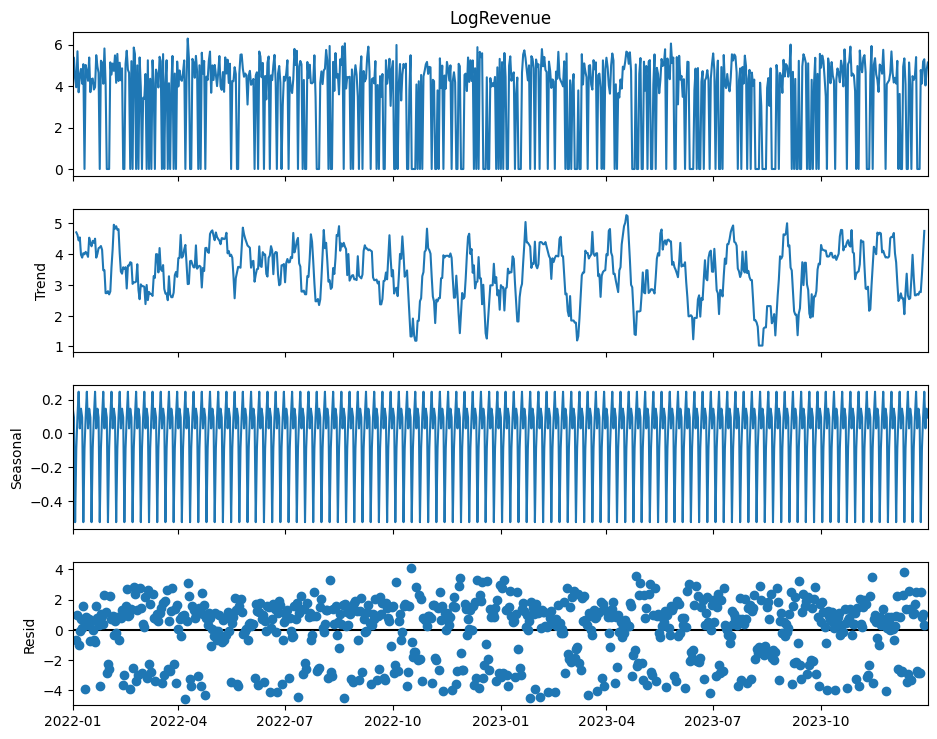

In [24]:
# 7. Decompose
# ==========================================
# Decompose the time series into Trend, Seasonal, and Residual components.
# We use the stabilized 'LogRevenue' for decomposition.
decomposition = seasonal_decompose(ts_data['LogRevenue'], model='additive', period=7)
ts_data['Trend'] = decomposition.trend
ts_data['Seasonal'] = decomposition.seasonal
ts_data['Resid'] = decomposition.resid

# Plotting the decomposition
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

In [28]:
# 8. Feature engineer
# ==========================================
# Create Lag features (past values) and Rolling means to help the model learn patterns.
# Lag 1: Revenue yesterday
# Lag 7: Revenue same day last week
ts_data['Lag_1'] = ts_data['LogRevenue'].shift(1)
ts_data['Lag_7'] = ts_data['LogRevenue'].shift(7)
ts_data['Rolling_Mean_7'] = ts_data['LogRevenue'].rolling(window=7).mean()

# Extract Date components for encoding
ts_data['DayOfWeek'] = ts_data.index.dayofweek  # 0=Monday, 6=Sunday
ts_data['Month'] = ts_data.index.month

# Drop NaN values created by lagging/differencing to prepare for modeling
model_data = ts_data.dropna().copy()

In [29]:
# 9. Encode
# ==========================================
# One-Hot Encode categorical features like DayOfWeek and Month.
# This converts them into binary columns (e.g., DayOfWeek_0, DayOfWeek_1).
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded_features = encoder.fit_transform(model_data[['DayOfWeek', 'Month']])
feature_names = encoder.get_feature_names_out(['DayOfWeek', 'Month'])

# Create a DataFrame for encoded features
encoded_df = pd.DataFrame(encoded_features, index=model_data.index, columns=feature_names)

# Combine lag features with encoded features
X = pd.concat([model_data[['Lag_1', 'Lag_7', 'Rolling_Mean_7']], encoded_df], axis=1)
y = model_data['LogRevenue']  # Target is the stabilized LogRevenue

# Ensure all column names are strings before scaling
X.columns = X.columns.astype(str)

In [35]:
# 10. Scale
# ==========================================
# Scale features to a range (0 to 1) using MinMaxScaler.
# This helps models converge faster and treats all features equally.
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)
X_scaled.head(3)

,Lag_1,Lag_7,Rolling_Mean_7,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
SignupDate,,,,,,,,,,,,,,,,,,,,
2022-01-08,0.717408,0.861142,0.848123,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-09,0.767281,0.852555,0.806075,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-01-10,0.654094,0.693799,0.829363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
# 11. Split
# ==========================================
# Split data into Training and Testing sets.
# IMPORTANT: For Time Series, we do NOT shuffle. We split by time (e.g., first 80% for train).
train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled.iloc[:train_size], X_scaled.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 576, Test size: 144


In [32]:
# 12. Model
# ==========================================
# Train a Linear Regression model (can be swapped for ARIMA/XGBoost).
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained.")

Model trained.



RMSE (Log Scale): 2.1400
MAE (Actual Currency): $74.30
RMSE (Actual Currency): $103.47


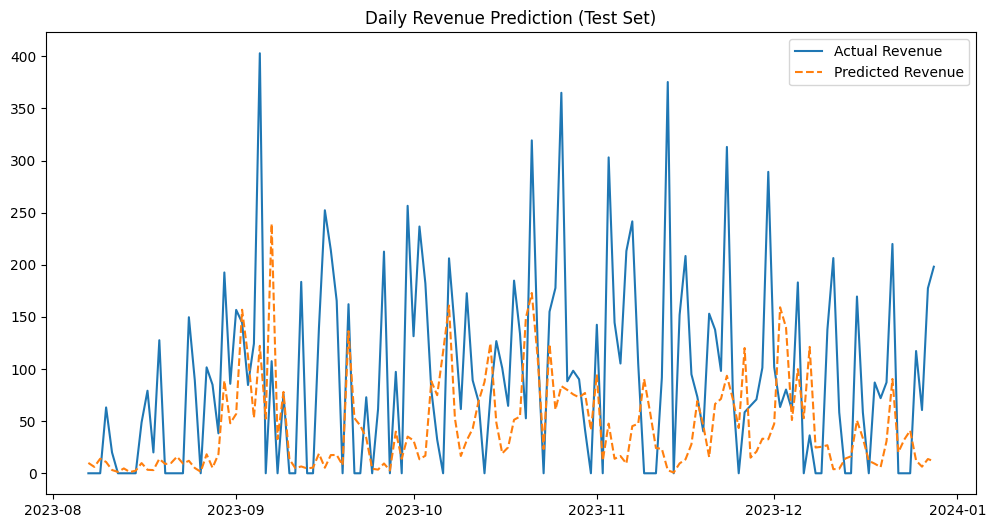

In [33]:
# 13. Evaluate
# ==========================================
# Make predictions on the test set and evaluate performance.
predictions_log = model.predict(X_test)

# Calculate RMSE on the Log Scale
rmse_log = np.sqrt(mean_squared_error(y_test, predictions_log))
print(f'\nRMSE (Log Scale): {rmse_log:.4f}')

# Inverse transform (exp) to interpret error in real currency (Daily Revenue)
predictions_actual = np.expm1(predictions_log)
y_test_actual = np.expm1(y_test)

mae_actual = mean_absolute_error(y_test_actual, predictions_actual)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))

print(f'MAE (Actual Currency): ${mae_actual:.2f}')
print(f'RMSE (Actual Currency): ${rmse_actual:.2f}')

# Plot Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual.index, y_test_actual, label='Actual Revenue')
plt.plot(y_test_actual.index, predictions_actual, label='Predicted Revenue', linestyle='--')
plt.title('Daily Revenue Prediction (Test Set)')
plt.legend()
plt.show()